In [13]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xccbf5e1dd3e78bcb, 0x9874f3c7559b32be, 0xd8514f69bff8ceeb, 0x82fdfc1896e41f73, 0x3fb8b484a812c1f9, 0xcd0ef6e307e7020f, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 100.0, r = 1.0, η = 1.01), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=40), r = Uniform{Float64}(a=1.0e-8, b=1.0), η = Uniform{Float64}(a=1.01, b=100.0)), Newtrinos.osc.var"#get_Nnaturalness#54"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig

In [4]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [5]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [6]:
p = Newtrinos.get_params(experiments)

(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [7]:
using Setfield

In [8]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 100.0, m₀ = 0.012464835956874186, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [9]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [10]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 59300.18489406855
 62051.16175453294
 56969.43305469504
 70147.23748674513
 78217.7434333644
 87150.81808346897
 87828.8560107417
 83120.71764727589
 78889.88931637548
 73594.9404257955
 66478.99307152472
 60144.22887070064
 54122.360313324716
 49262.46462897274
 44879.44697379161
 40041.565292455445
 33701.000234079234
 34695.06818205129
 25437.886255870028
 19936.861885068378
 14747.285229685536
  9930.05846702063
  6445.901449221073
  6779.037011614802
  3712.6138752753936
 17343.552744328474

In [11]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 59303.84615744453
 62052.49738752459
 56969.98451950954
 70145.47660777149
 78216.8564074401
 87153.80695373542
 87831.69302762367
 83115.37310206876
 78890.73195602273
 73591.37813701456
 66480.89045916275
 60142.27753110704
 54123.439067946994
 49261.04524055944
 44880.71618172892
 40040.842412001904
 33699.86954468065
 34696.59214714688
 25436.80373539392
 19936.47147791842
 14748.19210098824
  9930.0572530369
  6445.723518689674
  6778.89432268541
  3712.4220833862983
 17344.299888650225

In [12]:
using CairoMakie

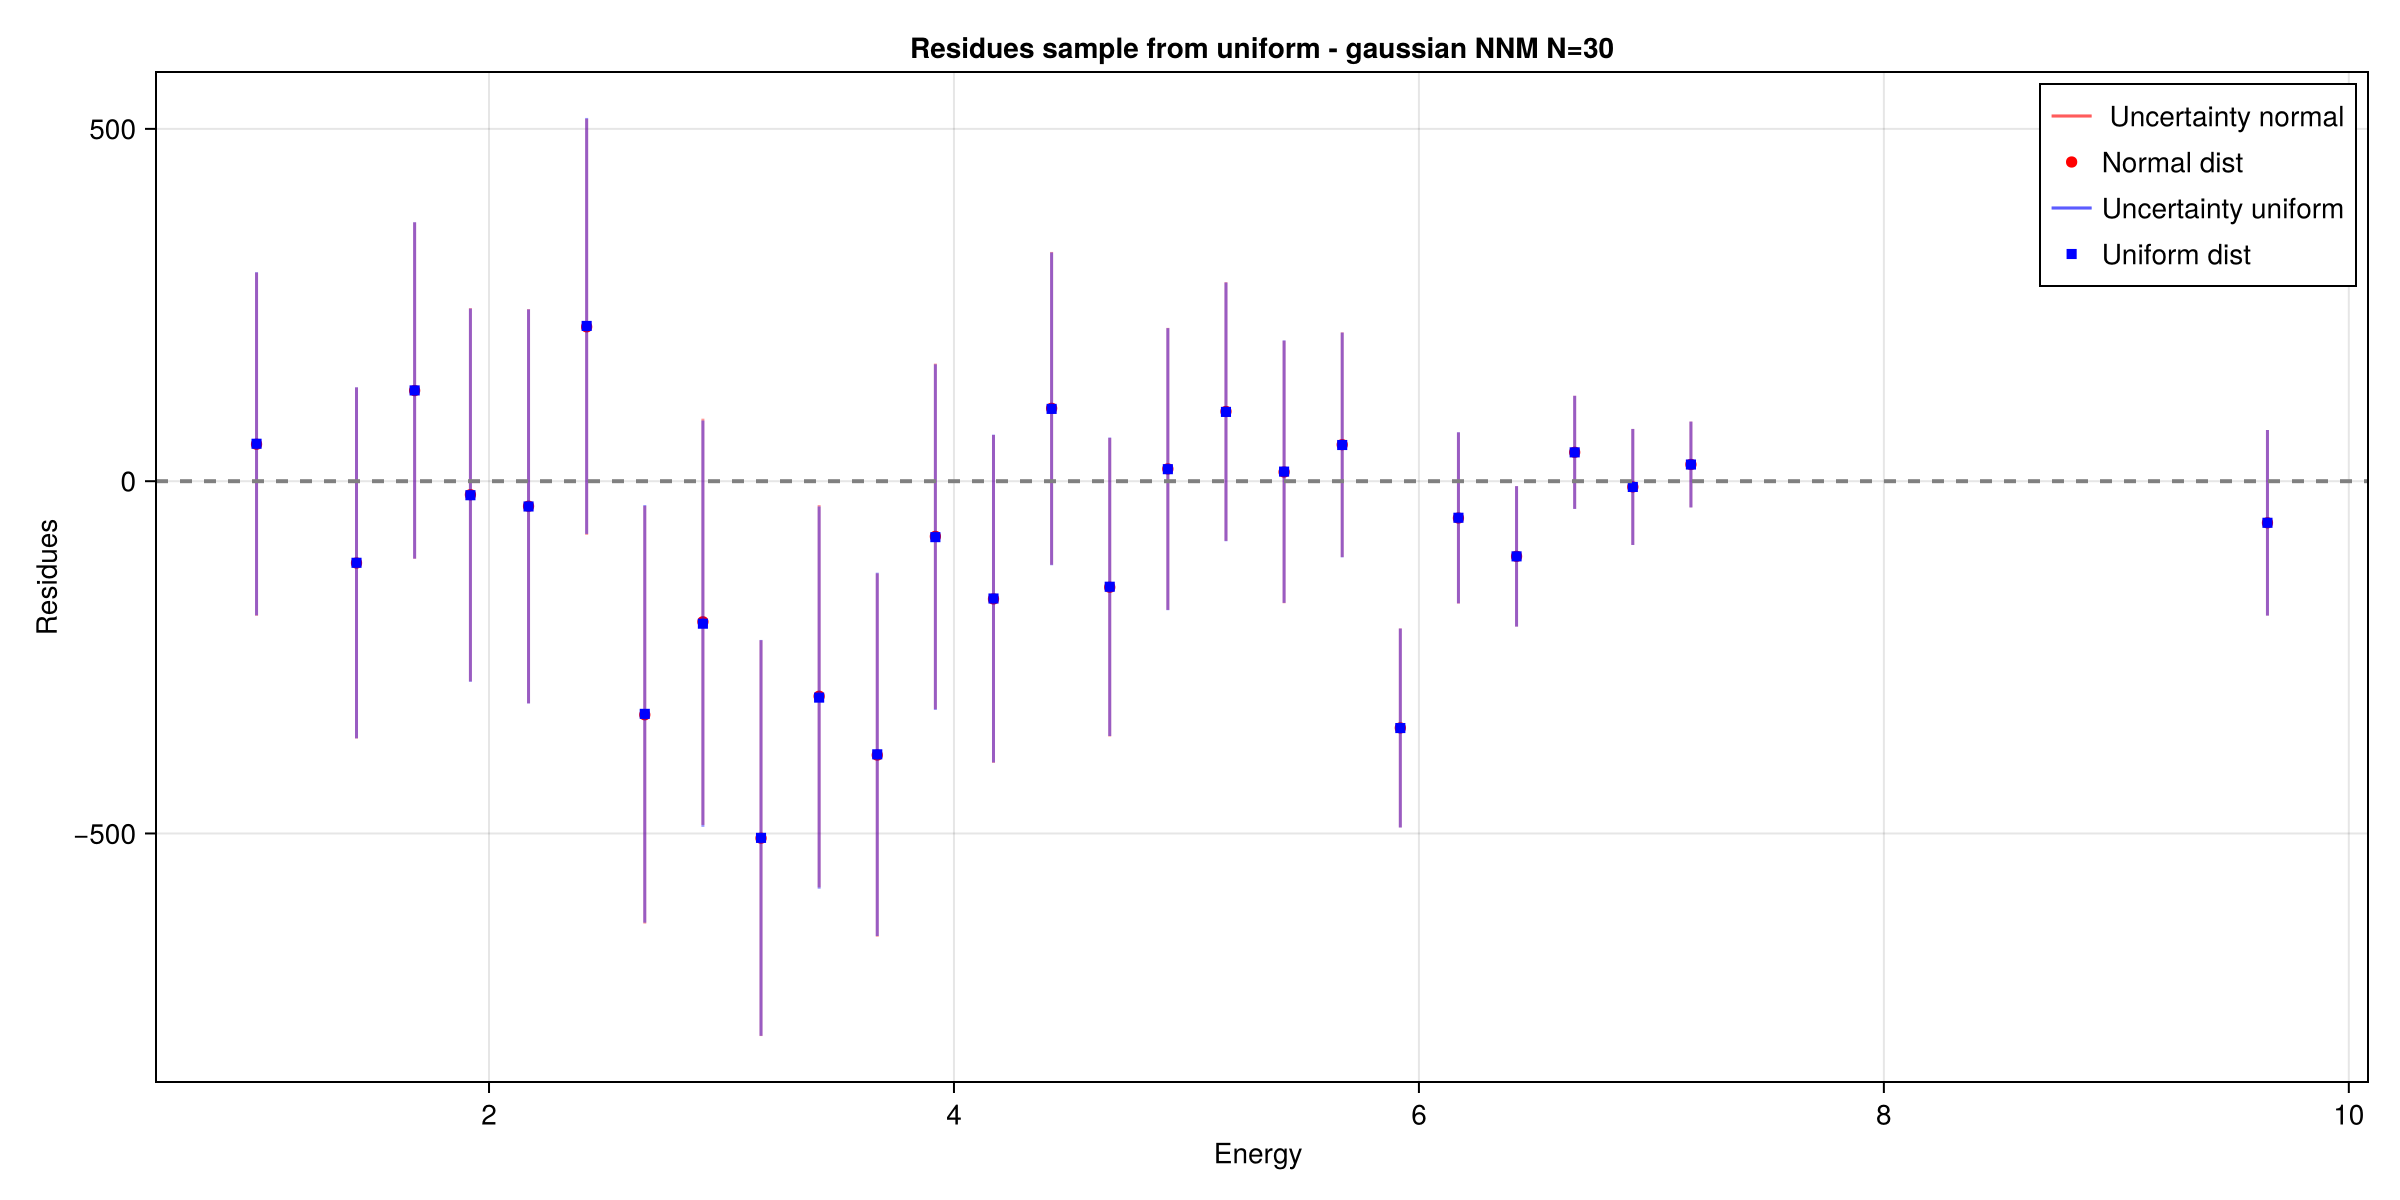

CairoMakie.Screen{IMAGE}


In [14]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=30")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [15]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [16]:

using ProgressMeter
using MeasureBase

In [17]:
function random_sampling(physics, experiments, p, N)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/100000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3)))
      new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm
      #p_new_un = @set p.N = N
      #p_new_norm = @set p.N = N


      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

    
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [18]:
trial=random_sampling(physics, experiments, p, 20)

Progress: 100%|█████████████████████████████████████████| Time: 2:56:25


([-168.61131363838336, -168.60574700681494, -168.58978268095666, -168.63175553278248, -168.62481488239033, -168.587762076792, -168.65138770205138, -168.62628523197378, -168.56840770593232, -168.57516811596815  …  -168.60531228903807, -168.62907260615222, -168.5914908891736, -168.59621210580016, -168.57919389279633, -168.60127128884568, -168.60013075815306, -168.60856981455157, -168.56873028286472, -168.60549928706732], [-168.66104957874467, -168.65298377797035, -168.64965522845415, -168.6374988662332, -168.60416147953308, -168.6690553218922, -168.6435416766306, -168.59695955742535, -168.6681302005245, -168.6024495800367  …  -168.62600849108256, -168.60201826506793, -168.66221352065145, -168.60321702134715, -168.66640239569975, -168.59962269819795, -168.64240069814701, -168.6385229645992, -168.6698417391359, -168.60492864039583])

In [19]:
trial=.-trial # to have the negative log likelihood

([168.61131363838336, 168.60574700681494, 168.58978268095666, 168.63175553278248, 168.62481488239033, 168.587762076792, 168.65138770205138, 168.62628523197378, 168.56840770593232, 168.57516811596815  …  168.60531228903807, 168.62907260615222, 168.5914908891736, 168.59621210580016, 168.57919389279633, 168.60127128884568, 168.60013075815306, 168.60856981455157, 168.56873028286472, 168.60549928706732], [168.66104957874467, 168.65298377797035, 168.64965522845415, 168.6374988662332, 168.60416147953308, 168.6690553218922, 168.6435416766306, 168.59695955742535, 168.6681302005245, 168.6024495800367  …  168.62600849108256, 168.60201826506793, 168.66221352065145, 168.60321702134715, 168.66640239569975, 168.59962269819795, 168.64240069814701, 168.6385229645992, 168.6698417391359, 168.60492864039583])

In [20]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

168.6383523807194

In [21]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc= Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  dayabay= Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

likelihood_SM=-logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

[ Info: Loading dayabay data


168.90003273508322

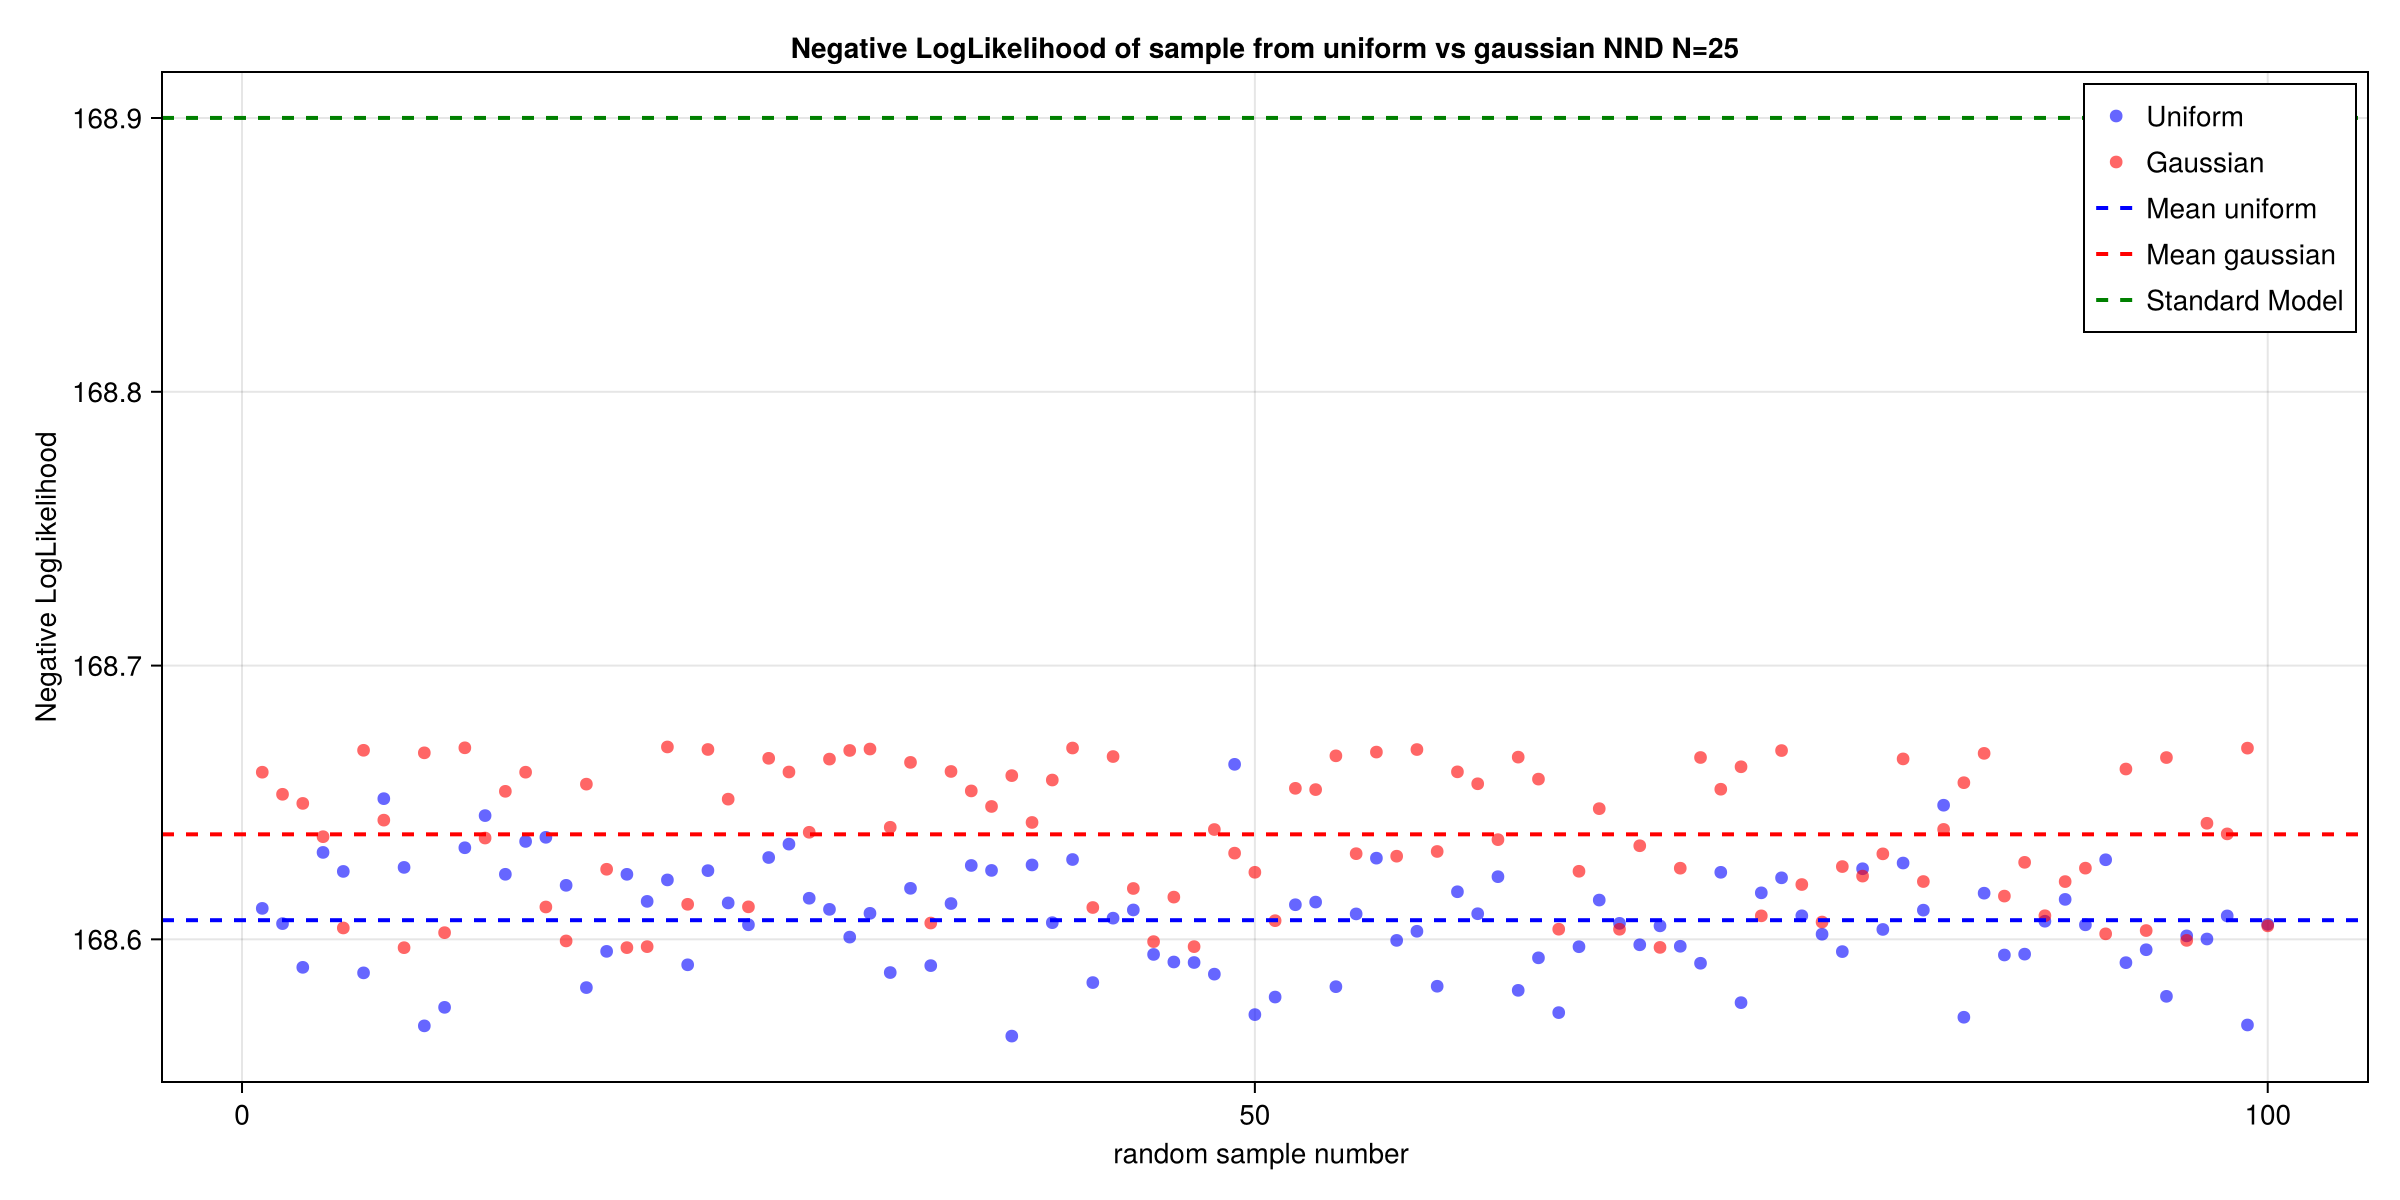

CairoMakie.Screen{IMAGE}


In [22]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=25")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_samples_NNM_N20_m0=0.1.png", fig)

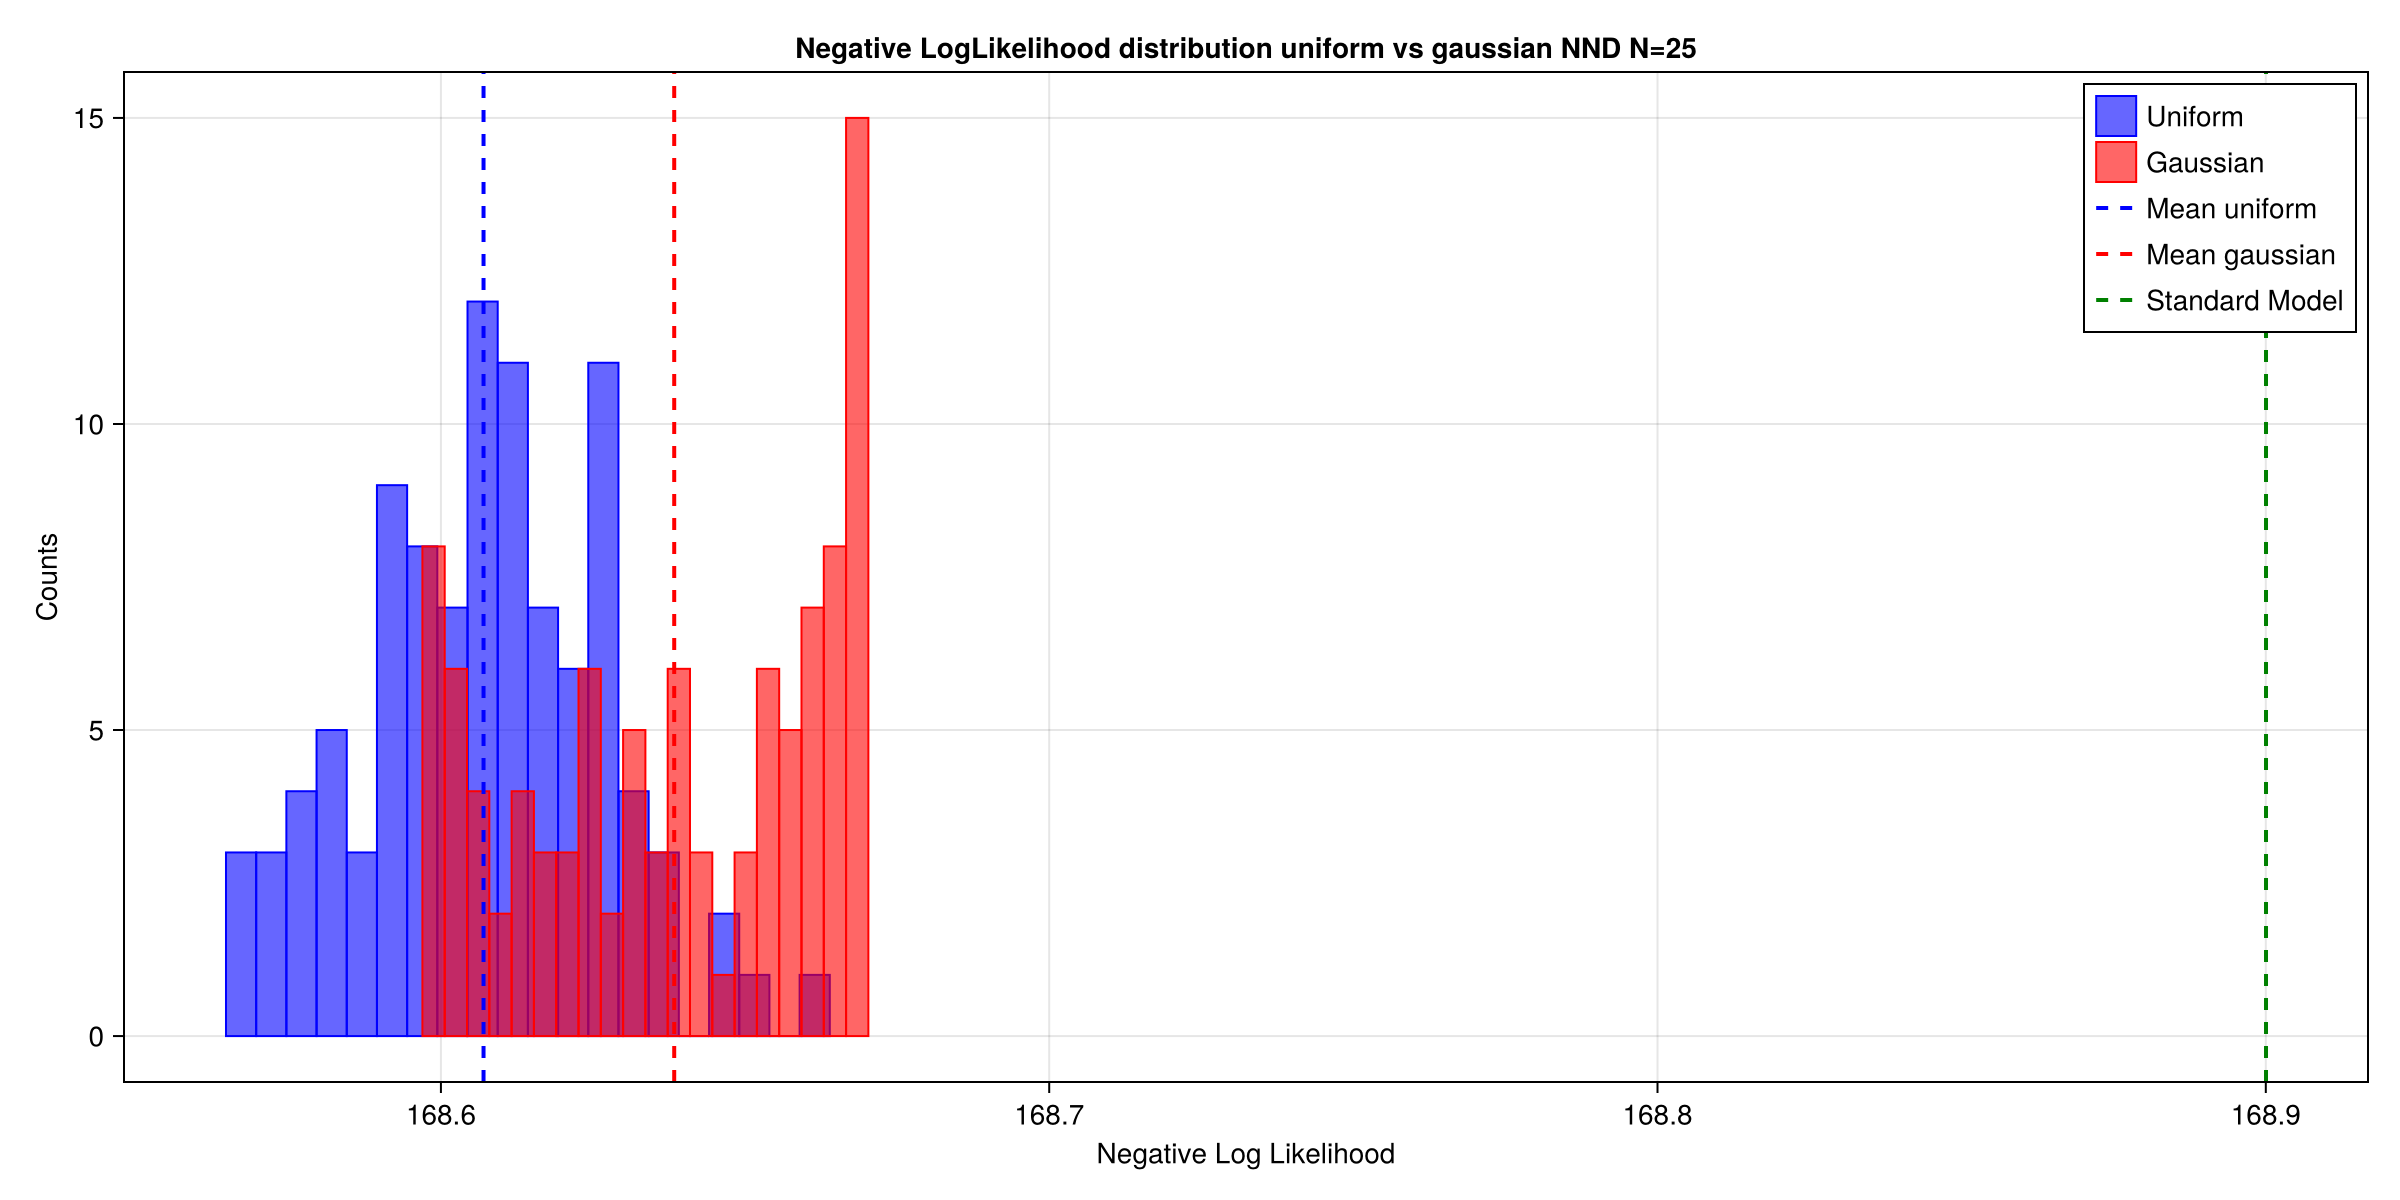

CairoMakie.Screen{IMAGE}


In [23]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=25")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_N25_m0=0.01.png", fig)

In [30]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    pvalue_un = Float64[]
    pvalue_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

   
    @showprogress for i in 20:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_a= (likelihood_SM-mean_un) # test SM (H0) vs uniform (H1)
       ratios_b= (mean_un-mean_norm) # test uniform (H0) vs gaussian (H1)

       push!(ratios_un, ratio_a)
       push!(ratios_norm, ratios_b)

       df_SM = 2
       df_r=1   # Difference in number of parameters

       p_value_a = 1 - cdf(Chisq(df_SM), ratio_a)
       p_value_b = 1 - cdf(Chisq(df_r), ratios_b)

        push!(pvalue_un, p_value_a)
        push!(pvalue_norm, p_value_b)

    end

     
    
    return ratios_un, ratios_norm, pvalue_un, pvalue_norm
end

lik_ratio (generic function with 1 method)

In [31]:
likelihood_ratios= lik_ratio(25)

Progress:  10%|████▏                                    |  ETA: 2:44:06

LoadError: InterruptException:

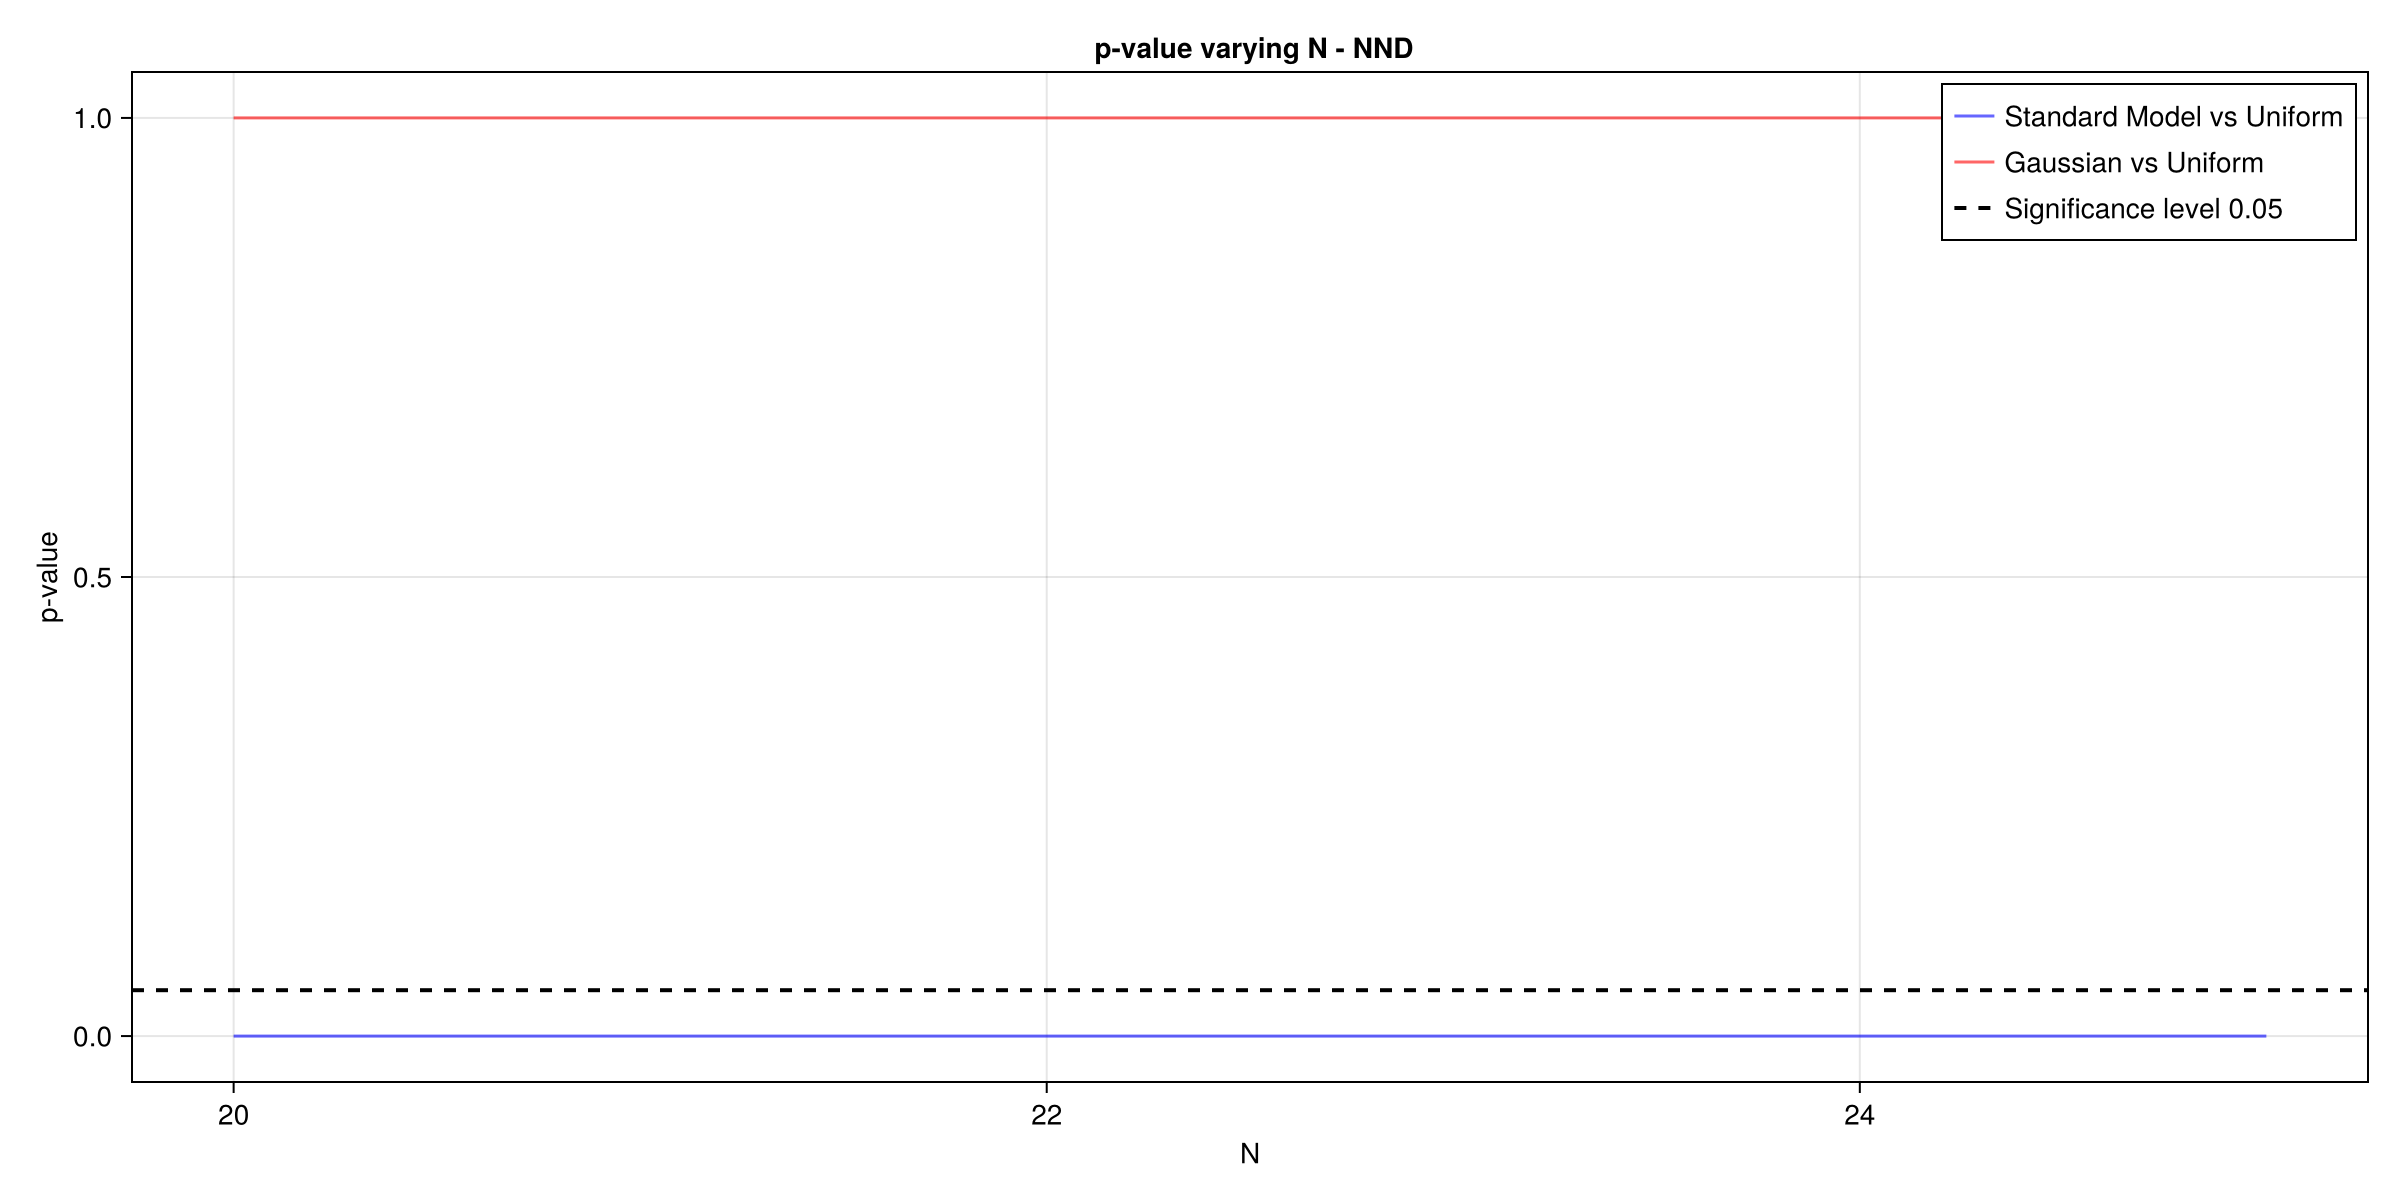

CairoMakie.Screen{IMAGE}


In [ ]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "p-value", 
    title = " p-value varying N - NND")

x=20:25
lines!(x, likelihood_ratios[:][3], color = (:blue, 0.6),  label = "Standard Model vs Uniform")
lines!(x, likelihood_ratios[:][4], color = (:red, 0.6),  label = "Gaussian vs Uniform")

hlines!(0.05, color = :black, linestyle = :dash, linewidth = 2, label = "Significance level 0.05")
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)


#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_r=1_pvalue.png", fig)